# Chapter 1: Exploratory Data Analysis
> (c) 2019-2026 Peter C. Bruce, Andrew Bruce, Peter Gedeck

In [1]:
from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI
from matplotlib.collections import EllipseCollection
from matplotlib.colors import Normalize
from scipy.stats import trim_mean
from statsmodels import robust
import matplotlib.pyplot as plt
import mlba
import numpy as np
import pandas as pd
import random
import seaborn as sns
import wquantiles

random.seed(123)

# Location of the data files. Adjust this path if you keep the data
# files in a different directory.
from pathlib import Path
DATA_DIR = Path('../../data')


## Exploratory Data Analysis
### Data Dictionaries and Catalogs

In [1]:
PROMPT = """
Improve the attached data dictionary and return it in YAML format. In addition
to the description of features, provide name, description, source, and size
of the dataset.

For each feature, provide the following information:
- feature name
- readable variable name (if required)
- definition of the variable
- data type
- measurement units
- allowed values (for categorical or nominal features, but only if you are sure)

Here is the data dictionary in YAML format:

{data_dictionary}

First ten lines of the dataset in CSV format:

{data_sample}
"""

In [1]:
chain = (
  PromptTemplate.from_template(PROMPT) |
  ChatOpenAI(model="gpt-5")
)

In [1]:
data_dictionary = """
name: ebay Auctions
description: >
    The dataset eBayAuctions.csv contains information on 1972 auctions that
    transacted on eBay.com during May-June 2004.
source: Copyright 2016 Galit Shmueli and Peter Bruce
size:
    observations: 1972
    features: 8
features:
    Category: Category of the auctioned item
    currency: "US: US dollar, GBP: English pound, EUR: Euro"
    sellerRating: >
        a rating by eBay, as a function of the number of "good" and  "bad"
        transactions the seller had on eBay
    Duration: Number of days the auction lasted (set by seller at auction start)
    endDay: Day of week that the auction closed
    ClosePrice: Price item sold at (converted into USD)
    OpenPrice: Initial price set by the seller (converted into USD)
    Competitive?: whether the auction had a single bid (0) or more (1)
"""

eBayAuctions = mlba.load_data("eBayAuctions")
data_sample = eBayAuctions.sample(10, random_state=123).to_csv(index=False)

context = {
    "data_dictionary": data_dictionary,
    "data_sample": data_sample,
}
result = chain.invoke(context)
print(result.content)

name: eBay Auctions (May–June 2004)
description: >
  Dataset of 1,972 completed auctions on eBay.com during May–June 2004.
  Records include listing category, listing currency, seller feedback rating,
  auction duration, day-of-week the auction ended, opening price (USD),
  closing price (USD), and an indicator of whether the auction received
  multiple bids (competitive). Note: OpenPrice and ClosePrice are converted
  to U.S. dollars regardless of the listing currency; currency records the
  currency in which the auction was originally listed.
source: Copyright 2016 Galit Shmueli and Peter Bruce (eBayAuctions.csv)
size:
  observations: 1972
  features: 8
features:
  - name: Category
    readable_name: category
    definition: Top-level category of the auctioned item as shown on the eBay listing.
    data_type: categorical (string)
    measurement_units: none

  - name: currency
    readable_name: listing_currency
    definition: Currency in which the auction was listed; prices in this

### Estimates of Location
#### Example: Location Estimates of Population and Murder Rates

In [1]:
state = pd.read_csv(DATA_DIR / "state.csv")
print(f"Mean: {state['Population'].mean()}")
print(f"Trimmed mean: {trim_mean(state['Population'], 0.1)}")
print(f"Median: {state['Population'].median()}")

Mean: 6162876.3
Trimmed mean: 4783697.125
Median: 4436369.5


In [1]:
weighted_mean = np.average(state["Murder.Rate"], weights=state["Population"])
weighted_quantile = wquantiles.median(state["Murder.Rate"],
                                      weights=state["Population"])
print(f"Weighted mean: {weighted_mean}")
print(f"Weighted median: {weighted_quantile}")

Weighted mean: 4.445833981123393
Weighted median: 4.4


### Estimates of Variability
#### Example: Variability Estimates of State Population

In [1]:
print(state["Population"].std())
print(state["Population"].quantile(0.75) - state["Population"].quantile(0.25))
print(robust.scale.mad(state["Population"]))

6848235.347401142
4847308.0
3849876.1459979336


### Exploring the Data Distribution
#### Percentiles and Boxplots

In [1]:
state[["Murder.Rate"]].quantile([0.05, 0.25, 0.5, 0.75, 0.95])

,Murder.Rate
0.05,1.600
0.25,2.425
0.50,4.000
0.75,5.550
0.95,6.510


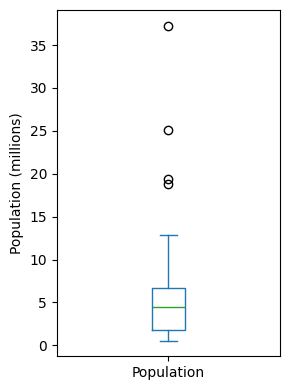

In [1]:
ax = (state["Population"] / 1_000_000).plot.box(figsize=(3, 4))
ax.set_ylabel("Population (millions)")

plt.tight_layout()
plt.show()

#### Frequency Tables and Histograms

In [1]:
binned_population = pd.cut(state["Population"], 10)
binned_population.value_counts()

Population
(526935.67, 4232659.0]      24
(4232659.0, 7901692.0]      14
(7901692.0, 11570725.0]      6
(11570725.0, 15239758.0]     2
(15239758.0, 18908791.0]     1
(18908791.0, 22577824.0]     1
(22577824.0, 26246857.0]     1
(33584923.0, 37253956.0]     1
(26246857.0, 29915890.0]     0
(29915890.0, 33584923.0]     0
Name: count, dtype: int64

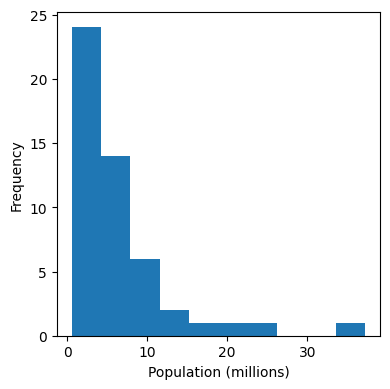

In [1]:
ax = (state["Population"] / 1_000_000).plot.hist(figsize=(4, 4))
ax.set_xlabel("Population (millions)")

plt.tight_layout()
plt.show()

#### Density Plots and Estimates

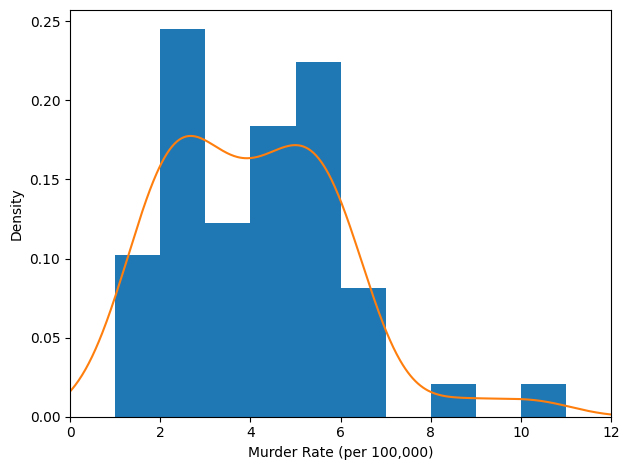

In [1]:
ax = state["Murder.Rate"].plot.hist(density=True, xlim=[0, 12],
    bins=range(1, 12))
state["Murder.Rate"].plot.density(ax=ax)
ax.set_xlabel("Murder Rate (per 100,000)")

plt.tight_layout()
plt.show()

### Exploring Binary and Categorical Data

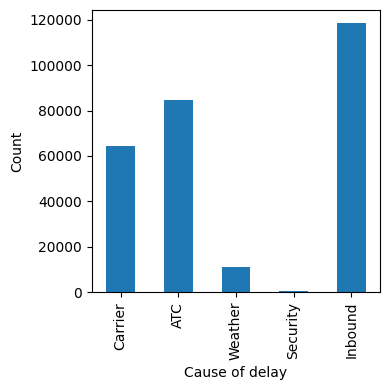

In [1]:
dfw = pd.read_csv(DATA_DIR / "dfw_airline.csv")
ax = dfw.transpose().plot.bar(figsize=(4, 4), legend=False)
ax.set_xlabel("Cause of delay")
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

### Correlation

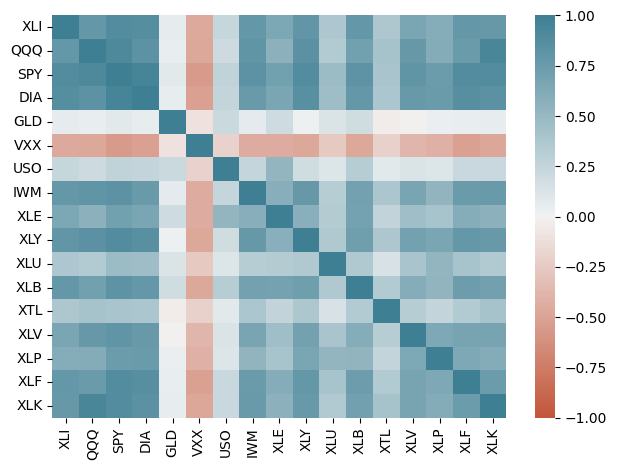

In [1]:
sp500_px = pd.read_csv(DATA_DIR / "sp500_data.csv.gz", index_col=0)
sp500_sym = pd.read_csv(DATA_DIR / "sp500_sectors.csv")
etf_symbols = sp500_sym[sp500_sym["sector"] == "etf"]["symbol"]
etfs = sp500_px.loc[sp500_px.index > "2012-07-01", etf_symbols]
sns.heatmap(etfs.corr(), vmin=-1, vmax=1,
  cmap=sns.diverging_palette(20, 220, as_cmap=True))

plt.tight_layout()
plt.show()

#### Scatterplots

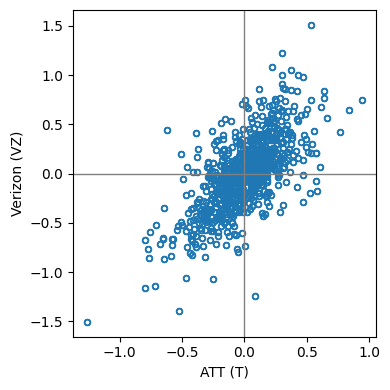

In [1]:
# Filter data for dates July 2012 through June 2015
telecom = sp500_px.loc[sp500_px.index >= "2012-07-01", :]

ax = telecom.plot.scatter(x="T", y="VZ", figsize=(4, 4), marker="$\u25EF$")
ax.set_xlabel("ATT (T)")
ax.set_ylabel("Verizon (VZ)")
ax.axhline(0, color="grey", lw=1)
ax.axvline(0, color="grey", lw=1)

plt.tight_layout()
plt.show()

### Exploring Two or More Variables
#### Hexagonal Binning and Contours pass:[<span class#"keep-together">(Plotting Numeric-Versus-Numeric Data)</span>]

In [1]:
kc_tax = pd.read_csv(DATA_DIR / "kc_tax.csv.gz")
kc_tax0 = kc_tax.loc[(kc_tax.TaxAssessedValue < 750000) &
                     (kc_tax.SqFtTotLiving > 100) &
                     (kc_tax.SqFtTotLiving < 3500), :]
kc_tax0.shape

(432693, 3)

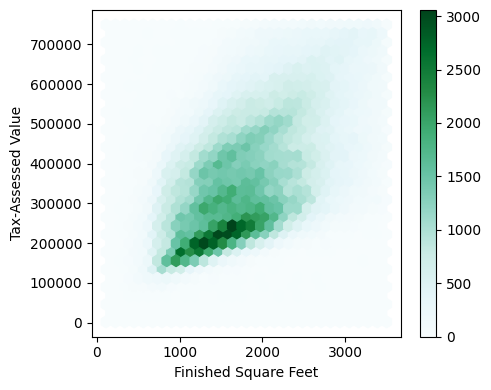

In [1]:
ax = kc_tax0.plot.hexbin(x="SqFtTotLiving", y="TaxAssessedValue",
                         gridsize=30, sharex=False, figsize=(5, 4))
ax.set_xlabel("Finished Square Feet")
ax.set_ylabel("Tax-Assessed Value")

plt.tight_layout()
plt.show()

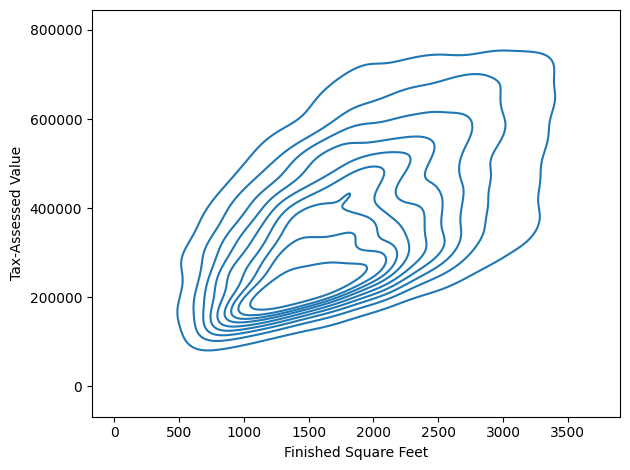

In [1]:
ax = sns.kdeplot(data=kc_tax0.sample(10000), x="SqFtTotLiving",
    y="TaxAssessedValue")
ax.set_xlabel("Finished Square Feet")
ax.set_ylabel("Tax-Assessed Value")

plt.tight_layout()
plt.show()

#### Two Categorical Variables

In [1]:
lc_loans = pd.read_csv(DATA_DIR / "lc_loans.csv")

crosstab = lc_loans.pivot_table(index="grade", columns="status",
                                aggfunc=len, margins=True)
print(crosstab)

df = crosstab.loc["A":"G", :].copy()
perc_crosstab = df.loc[:, "Charged Off":"Late"].div(df["All"], axis=0)
perc_crosstab["All"] = df["All"] / sum(df["All"])
print(perc_crosstab)

status  Charged Off  Current  Fully Paid  Late     All
grade                                                 
A              1562    50051       20408   469   72490
B              5302    93852       31160  2056  132370
C              6023    88928       23147  2777  120875
D              5007    53281       13681  2308   74277
E              2842    24639        5949  1374   34804
F              1526     8444        2328   606   12904
G               409     1990         643   199    3241
All           22671   321185       97316  9789  450961
status  Charged Off   Current  Fully Paid      Late       All
grade                                                        
A          0.021548  0.690454    0.281528  0.006470  0.160746
B          0.040054  0.709013    0.235401  0.015532  0.293529
C          0.049828  0.735702    0.191495  0.022974  0.268039
D          0.067410  0.717328    0.184189  0.031073  0.164708
E          0.081657  0.707936    0.170929  0.039478  0.077177
F          0.118

#### Categorical and Numeric Data

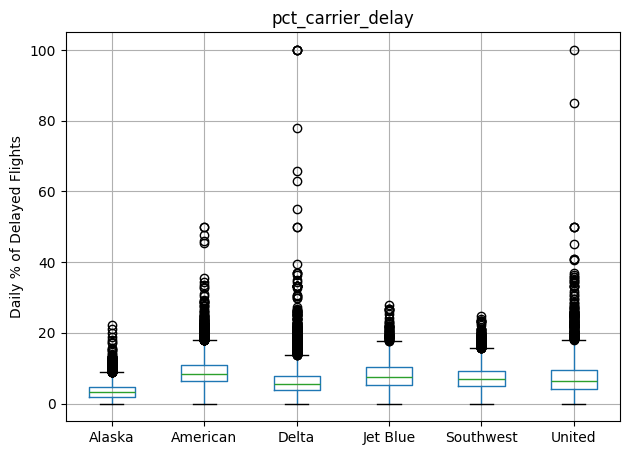

In [1]:
airline_stats = pd.read_csv(DATA_DIR / "airline_stats.csv")
ax = airline_stats.boxplot(by="airline", column="pct_carrier_delay")
ax.set_xlabel("")
ax.set_ylabel("Daily % of Delayed Flights")
plt.suptitle("")

plt.tight_layout()
plt.show()

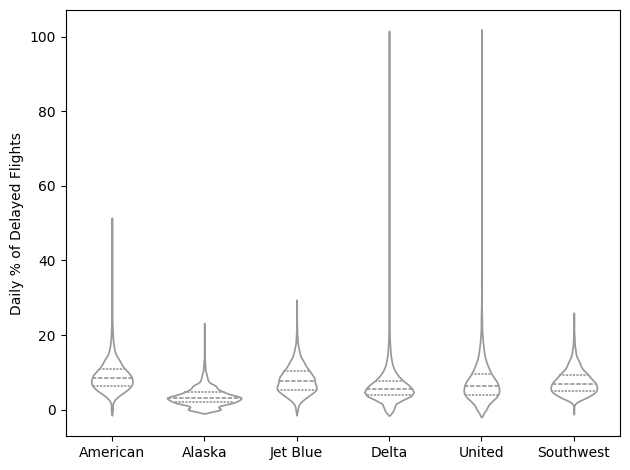

In [1]:
ax = sns.violinplot(data=airline_stats, x="airline", y="pct_carrier_delay",
                    inner="quartile", color="white")
ax.set_xlabel("")
ax.set_ylabel("Daily % of Delayed Flights")

plt.tight_layout()
plt.show()

#### Visualizing Multiple Variables

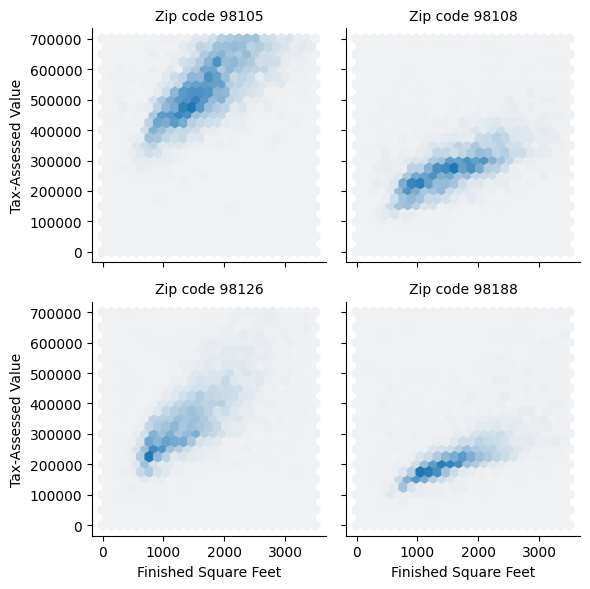

In [1]:
zip_codes = [98188, 98105, 98108, 98126]
kc_tax_zip = kc_tax0.loc[kc_tax0.ZipCode.isin(zip_codes), :]

def hexbin(x, y, color, **kwargs):
    cmap = sns.light_palette(color, as_cmap=True)
    plt.hexbin(x, y, gridsize=25, cmap=cmap, **kwargs)

g = sns.FacetGrid(kc_tax_zip, col="ZipCode", col_wrap=2)
g.map(hexbin, "SqFtTotLiving", "TaxAssessedValue",
      extent=[0, 3500, 0, 700000])
g.set_axis_labels("Finished Square Feet", "Tax-Assessed Value")
g.set_titles("Zip code {col_name:.0f}")

plt.tight_layout()
plt.show()

# Supplementary Material
## Table 1-2. A few rows of the data.frame state of population and murder rate by state

In [1]:
print(state.head(8))

         State  Population  Murder.Rate Abbreviation
0      Alabama     4779736          5.7           AL
1       Alaska      710231          5.6           AK
2      Arizona     6392017          4.7           AZ
3     Arkansas     2915918          5.6           AR
4   California    37253956          4.4           CA
5     Colorado     5029196          2.8           CO
6  Connecticut     3574097          2.4           CT
7     Delaware      897934          5.8           DE


## Table 1-4. Percentiles of murder rate by state

In [1]:
percentages = [0.05, 0.25, 0.5, 0.75, 0.95]
df = pd.DataFrame(state["Murder.Rate"].quantile(percentages))
df.index = [f"{p * 100}%" for p in percentages]
print(df.transpose())

             5.0%  25.0%  50.0%  75.0%  95.0%
Murder.Rate   1.6  2.425    4.0   5.55   6.51


## Table 1-5. A frequency table of population by state

In [1]:
binnedPopulation = pd.cut(state["Population"], 10)
print(binnedPopulation.value_counts())

binnedPopulation.name = "binnedPopulation"
df = pd.concat([state, binnedPopulation], axis=1)
df = df.sort_values(by="Population")

groups = []
for group, subset in df.groupby(by="binnedPopulation", observed=False):
    groups.append({
        "BinRange": group,
        "Count": len(subset),
        "States": ",".join(subset.Abbreviation),
    })
pd.DataFrame(groups)

Population
(526935.67, 4232659.0]      24
(4232659.0, 7901692.0]      14
(7901692.0, 11570725.0]      6
(11570725.0, 15239758.0]     2
(15239758.0, 18908791.0]     1
(18908791.0, 22577824.0]     1
(22577824.0, 26246857.0]     1
(33584923.0, 37253956.0]     1
(26246857.0, 29915890.0]     0
(29915890.0, 33584923.0]     0
Name: count, dtype: int64


,BinRange,Count,States
0,"(526935.67, 4232659.0]",24,"WY,VT,ND,AK,SD,DE,MT,RI,NH,ME,HI,ID,NE,WV,NM,N..."
1,"(4232659.0, 7901692.0]",14,"KY,LA,SC,AL,CO,MN,WI,MD,MO,TN,AZ,IN,MA,WA"
2,"(7901692.0, 11570725.0]",6,"VA,NJ,NC,GA,MI,OH"
3,"(11570725.0, 15239758.0]",2,"PA,IL"
4,"(15239758.0, 18908791.0]",1,FL
5,"(18908791.0, 22577824.0]",1,NY
6,"(22577824.0, 26246857.0]",1,TX
7,"(26246857.0, 29915890.0]",0,
8,"(29915890.0, 33584923.0]",0,
9,"(33584923.0, 37253956.0]",1,CA


## Table 1-6. Percentage of delays by cause at Dallas/Fort Worth Airport

In [1]:
dfw = pd.read_csv(DATA_DIR / "dfw_airline.csv")
print(100 * dfw / dfw.to_numpy().sum())

     Carrier        ATC   Weather  Security    Inbound
0  23.022989  30.400781  4.025214  0.122937  42.428079


## Table 1-7. Correlation between telecommunication stock returns

In [1]:
telecomSymbols = sp500_sym[sp500_sym["sector"] == "telecommunications_services"]["symbol"]

# Filter data for dates July 2012 through June 2015
telecom = sp500_px.loc[sp500_px.index >= "2012-07-01", telecomSymbols]
telecom.corr()
print(telecom)

                   T       CTL       FTR        VZ      LVLT
Date                                                        
2012-07-02  0.422496  0.140847  0.070879  0.554180 -0.519998
2012-07-03 -0.177448  0.066280  0.070879 -0.025976 -0.049999
2012-07-05 -0.160548 -0.132563  0.055128 -0.051956 -0.180000
2012-07-06  0.342205  0.132563  0.007875  0.140106 -0.359999
2012-07-09  0.136883  0.124279 -0.023626  0.253943  0.180000
...              ...       ...       ...       ...       ...
2015-06-25  0.049342 -1.600000 -0.040000 -0.187790 -0.330002
2015-06-26 -0.256586  0.039999 -0.070000  0.029650 -0.739998
2015-06-29 -0.098685 -0.559999 -0.060000 -0.504063 -1.360000
2015-06-30 -0.503298 -0.420000 -0.070000 -0.523829  0.199997
2015-07-01 -0.019737  0.080000 -0.050000  0.355811  0.139999

[754 rows x 5 columns]


In [1]:
etfs = sp500_px.loc[sp500_px.index > "2012-07-01",
                    sp500_sym[sp500_sym["sector"] == "etf"]["symbol"]]
print(etfs.head())

                 XLI       QQQ       SPY       DIA       GLD    VXX       USO  \
Date                                                                            
2012-07-02 -0.376098  0.096313  0.028223 -0.242796  0.419998 -10.40  0.000000   
2012-07-03  0.376099  0.481576  0.874936  0.728405  0.490006  -3.52  0.250000   
2012-07-05  0.150440  0.096313 -0.103487  0.149420  0.239991   6.56 -0.070000   
2012-07-06 -0.141040 -0.491201  0.018819 -0.205449 -0.519989  -8.80 -0.180000   
2012-07-09  0.244465 -0.048160 -0.056445 -0.168094  0.429992  -0.48  0.459999   

                 IWM       XLE       XLY       XLU       XLB       XTL  \
Date                                                                     
2012-07-02  0.534641  0.028186  0.095759  0.098311 -0.093713  0.019076   
2012-07-03  0.926067  0.995942  0.000000 -0.044686  0.337373  0.000000   
2012-07-05 -0.171848 -0.460387  0.306431 -0.151938  0.103086  0.019072   
2012-07-06 -0.229128  0.206706  0.153214  0.080437  0.018744 -

## Figure 1-6. Correlation between ETF returns (Python version)

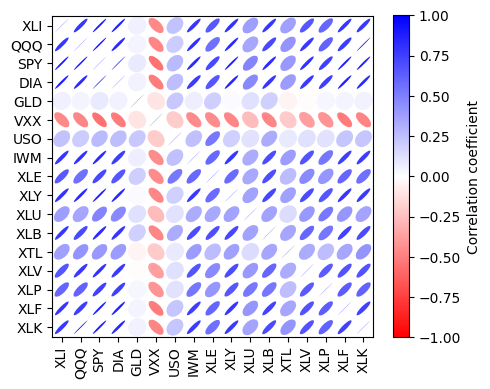

In [1]:
def plot_corr_ellipses(data, figsize=None, **kwargs):
    """ https://stackoverflow.com/a/34558488 """
    m = np.array(data)
    if not m.ndim == 2:
        raise ValueError("data must be a 2D array")
    _, ax = plt.subplots(1, 1, figsize=figsize, subplot_kw={"aspect": "equal"})
    ax.set_xlim(-0.5, m.shape[1] - 0.5)
    ax.set_ylim(-0.5, m.shape[0] - 0.5)
    ax.invert_yaxis()

    # xy locations of each ellipse center
    xy = np.indices(m.shape)[::-1].reshape(2, -1).T

    # set the relative sizes of the major/minor axes according to the strength of
    # the positive/negative correlation
    w = np.ones_like(m).ravel() + 0.01
    h = 1 - np.abs(m).ravel() - 0.01
    a = 45 * np.sign(m).ravel()

    ec = EllipseCollection(widths=w, heights=h, angles=a, units="x", offsets=xy,
                           norm=Normalize(vmin=-1, vmax=1),
                           transOffset=ax.transData, array=m.ravel(), **kwargs)
    ax.add_collection(ec)

    # if data is a DataFrame, use the row/column names as tick labels
    if isinstance(data, pd.DataFrame):
        ax.set_xticks(np.arange(m.shape[1]))
        ax.set_xticklabels(data.columns, rotation=90)
        ax.set_yticks(np.arange(m.shape[0]))
        ax.set_yticklabels(data.index)

    return ec, ax

m, ax = plot_corr_ellipses(etfs.corr(), figsize=(5, 4), cmap="bwr_r")
cb = plt.colorbar(m, ax=ax)
cb.set_label("Correlation coefficient")

plt.tight_layout()
plt.show()

## Figure 1-6. Correlation between ETF returns using a heat map (R version)